Import necessary packages

In [2]:
import networkx as nx
import json
from networkx.readwrite import json_graph
from collections import defaultdict
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from community import community_louvain
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import pandas as pd
from wordcloud import WordCloud

Create function to load data in a proper format

In [3]:
def parse_rfa(file_path):
    with open(file_path, 'rt', encoding='utf-8') as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

Create a function that builds the graph

In [4]:
def build_voter_graph(data):
    votes_by_candidate = defaultdict(list)

    for d in data:
        src = d.get("SRC", "").strip()
        tgt = d.get("TGT", "").strip()

        if not src or not tgt:
            continue

        vote = int(d["VOT"])

        # skip neutral votes
        if vote == 0:
            continue

        votes_by_candidate[tgt].append((src, vote))

    G = nx.Graph()

    for cand, voter_list in votes_by_candidate.items():
        for (u, vote_u), (v, vote_v) in combinations(voter_list, 2):

            pair_weight = vote_u * vote_v  # +1 agreement, -1 disagreement

            if G.has_edge(u, v):
                G[u][v]["weight"] += pair_weight
                G[u][v]["count"] += 1
            else:
                G.add_edge(u, v, weight=pair_weight, count=1)
        
    for u, v, data in G.edges(data=True):
        data["normalized"] = round(data["weight"] / data["count"], 5)

    return G

Build the graph and check for amount of nodes and edges

In [5]:
data = parse_rfa("wiki-RfA.txt")
G = build_voter_graph(data)

print("Voter graph:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

print(list(G.edges(data=True))[:10])

Voter graph:
Nodes: 10283
Edges: 3055279
[('Steel1943', 'Cuchullain', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'INeverCry', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Cncmaster', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Miniapolis', {'weight': 0, 'count': 2, 'normalized': 0.0}), ('Steel1943', 'Sven Manguard', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Ramaksoud2000', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'RockMagnetist', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Carrite', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Someguy1221', {'weight': 1, 'count': 1, 'normalized': 1.0}), ('Steel1943', 'Secret', {'weight': 0, 'count': 2, 'normalized': 0.0})]


Saves graph as .json file

In [6]:
proj = json_graph.node_link_data(G)

with open("voter_graph.json", "w") as f:
    json.dump(proj, f)

Amount of edges appears to be far too big. Checking for distribution and percentiles of counts

In [7]:
# distribution of counts
counts = [d["count"] for _, _, d in G.edges(data=True)]

print("Min:", min(counts))
print("Max:", max(counts))
print("Average:", sum(counts)/len(counts))

# percentiles
counts = np.array([d["count"] for _, _, d in G.edges(data=True)])

print("Percentiles:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(counts, p))

Min: 1
Max: 672
Average: 3.5340612101218905
Percentiles:
50th percentile: 1.0
75th percentile: 3.0
80th percentile: 4.0
90th percentile: 7.0
95th percentile: 12.0
99th percentile: 35.0


Appears to be a lot of noise among the edges with a small number of co-votes. Decides to create a threshold of 4 minimum co-votes to create an edges to avoid creating a graph that is too big and noisy

Creates 2 filtered graphs: G_agree for co-voters with mostly agreement, and G_disagree for co-voters with mostly disagreement

In [8]:
G_agree = nx.Graph()
G_disagree = nx.Graph()

for u, v, data in G.edges(data=True):
    c = data["count"]
    n = data["normalized"]
    w = data["weight"]

    # Keep only edges with enough evidence
    if c < 4:
        continue

    # Agreement graph
    if n > 0:
        G_agree.add_edge(
            u,
            v,
            count=c,
            weight=w,
            normalized=n,
            community_weight=n
        )

    # Disagreement graph
    elif n < 0:
        G_disagree.add_edge(
            u,
            v,
            count=c,
            weight=abs(w),
            normalized=n,
            community_weight=abs(n)
        )

print("Agree graph:")
print("Nodes:", G_agree.number_of_nodes())
print("Edges:", G_agree.number_of_edges())

print("\nDisagree graph:")
print("Nodes:", G_disagree.number_of_nodes())
print("Edges:", G_disagree.number_of_edges())

Agree graph:
Nodes: 5106
Edges: 498430

Disagree graph:
Nodes: 4317
Edges: 105995


Save agreement graph

In [9]:
agree = json_graph.node_link_data(G_agree)

with open("agree_graph.json", "w", encoding="utf-8") as f:
    json.dump(agree, f)

Save disagreement graph

In [10]:
disagree = json_graph.node_link_data(G_disagree)

with open("disagree_graph.json", "w", encoding="utf-8") as f:
    json.dump(disagree, f)

Community detection for agreement graph with a fixed random seed for reproducibility

In [11]:
partition_agree = community_louvain.best_partition(
    G_agree,
    weight="community_weight",
    random_state=42
)

Basic summary

In [12]:
num_communities = len(set(partition_agree.values()))
print("Number of communities:", num_communities)

community_sizes = Counter(partition_agree.values())
print("\nLargest communities:")
for comm, size in community_sizes.most_common(10):
    print(f"Community {comm}: {size} nodes")

Number of communities: 6

Largest communities:
Community 5: 1694 nodes
Community 2: 1318 nodes
Community 3: 1085 nodes
Community 0: 991 nodes
Community 4: 14 nodes
Community 1: 4 nodes


Attach community labels to the graph

In [13]:
nx.set_node_attributes(G_agree, partition_agree, "community")

Save graph with communites

In [14]:
com = json_graph.node_link_data(G_agree)

with open("agree_graph_communities.json", "w", encoding="utf-8") as f:
    json.dump(com, f)

Checking if all voters have been assigned to a community

In [15]:
node_to_community = {
    node: attrs["community"]
    for node, attrs in G_agree.nodes(data=True)
    if "community" in attrs
}

print("Nodes with community labels:", len(node_to_community))

Nodes with community labels: 5106


Checking how many texts there are in total

In [16]:
def parse_rfa(file_path):
    with open(file_path, "rt", encoding="utf-8") as f:
        content = f.read()

    entries = content.strip().split("\n\n")
    data = []

    for entry in entries:
        record = {}
        for line in entry.split("\n"):
            if ":" in line:
                key, value = line.split(":", 1)
                record[key.strip()] = value.strip()
        data.append(record)

    return data

records = parse_rfa("wiki-RfA.txt")
print("Records:", len(records))

Records: 198275


Checking for each community

In [17]:
texts_by_community = defaultdict(list)

for r in records:
    src = r.get("SRC")
    txt = r.get("TXT", "").strip()

    if not txt:
        continue

    if src in node_to_community:
        comm = node_to_community[src]
        texts_by_community[comm].append(txt)

for comm, texts in texts_by_community.items():
    print(f"Community {comm}: {len(texts)} texts")

Community 0: 32894 texts
Community 2: 47914 texts
Community 5: 63989 texts
Community 3: 38739 texts
Community 4: 39 texts
Community 1: 10 texts


Appears to be a sufficient amount for the 4 largest communities, but not so much for the 2 small ones. Will keep this in mind when analyzing TF-IDF and Wordclouds

Defines each community to be 1 document

In [18]:
community_ids = sorted(texts_by_community.keys())
community_documents = [
    " ".join(texts_by_community[comm])
    for comm in community_ids
]

print("Number of community documents:", len(community_documents))

Number of community documents: 6


Defines stopwords for filtering

In [20]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreasstampedalgaard/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Defines additional custom stopwords to remove noise

In [21]:
custom_stopwords = {
    "support", "oppose", "neutral",
    "wikipedia", "wiki", "user", "editor",
    "admin", "candidate", "rfa",
    "vote", "voted", "voting",
    "page", "article",
    "would", "could", "should", "also",
    "one", "two", "well", "like", "think",
    "see", "really", "much", "many",
    "per", "however", "since",
    "make", "made",
    "nbsp", "mdash", "ndash", "nom"
}

all_stopwords = stop_words.union(custom_stopwords)

Creates a function to filter text to remove noise, mistakes, errors, links, weird symbols and the likes

In [22]:
def clean_text(text):
    text = text.lower()
    
    text = re.sub(r"\[\[.*?\]\]", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"'{2,}", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    tokens = text.split()
    
    tokens = [
        w for w in tokens
        if w not in all_stopwords and len(w) > 2
    ]
    
    return " ".join(tokens)

Applies function to documents

In [23]:
community_documents = [
    " ".join(clean_text(t) for t in texts_by_community[c])
    for c in community_ids
]

Calculates TF-IDF and saves in DataFrame

In [24]:
vectorizer = TfidfVectorizer(
    stop_words=None,
    max_df=0.9,
    min_df=1,
    ngram_range=(1, 2)        
)

X = vectorizer.fit_transform(community_documents)
terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X.toarray(),
    index=[f"community_{c}" for c in community_ids],
    columns=terms
)

Finds top TF-IDF words for each community

In [25]:
for comm in community_ids:
    row = tfidf_df.loc[f"community_{comm}"]
    top_terms = row.sort_values(ascending=False).head(20)

    print(f"\nTop TF-IDF terms for community {comm}:")
    for term, score in top_terms.items():
        print(f"{term}: {score:.4f}")


Top TF-IDF terms for community 0:
work: 0.2773
tools: 0.2274
experience: 0.2261
time: 0.1698
concerns: 0.1663
edits: 0.1647
content: 0.1463
contributions: 0.1398
enough: 0.1370
answers: 0.1340
seems: 0.1260
great: 0.1241
questions: 0.1128
areas: 0.1124
months: 0.1021
seen: 0.1016
answer: 0.1011
reason: 0.1009
need: 0.0999
project: 0.0983

Top TF-IDF terms for community 1:
ghirlandajo: 0.2350
alex: 0.2174
rights: 0.1305
contributors: 0.1305
alex bakharev: 0.1007
bakharev: 0.1007
disputes: 0.0870
willing: 0.0870
russian: 0.0870
trolls: 0.0870
insulted: 0.0870
wars wishing: 0.0849
giving ghirlandajo: 0.0849
anonymous trolls: 0.0849
wanting posess: 0.0849
alex nice: 0.0849
users insulted: 0.0849
users contributors: 0.0849
unwilling provoke: 0.0849
alex division: 0.0849

Top TF-IDF terms for community 2:
tools: 0.2916
work: 0.2388
experience: 0.2348
edits: 0.1903
time: 0.1637
great: 0.1395
enough: 0.1357
concerns: 0.1241
contributions: 0.1229
seems: 0.1200
answers: 0.1191
project: 0.1114
n

Creates wordclouds for each community

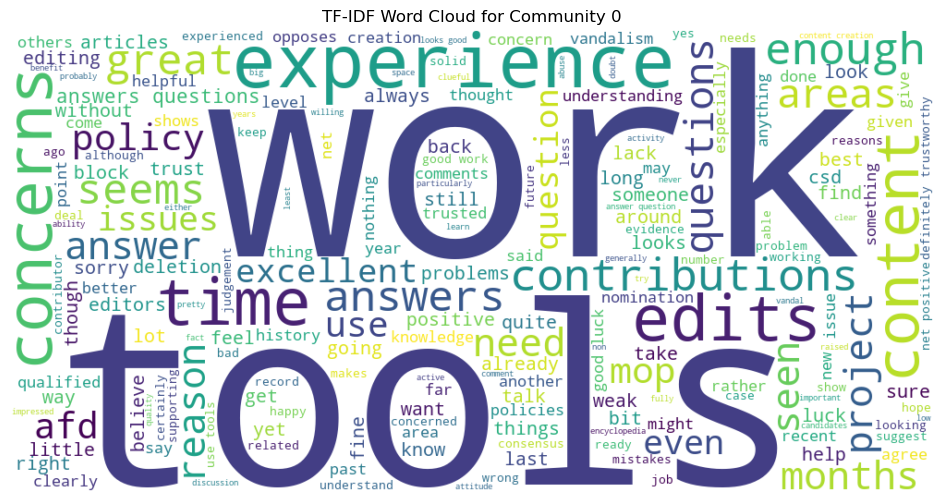

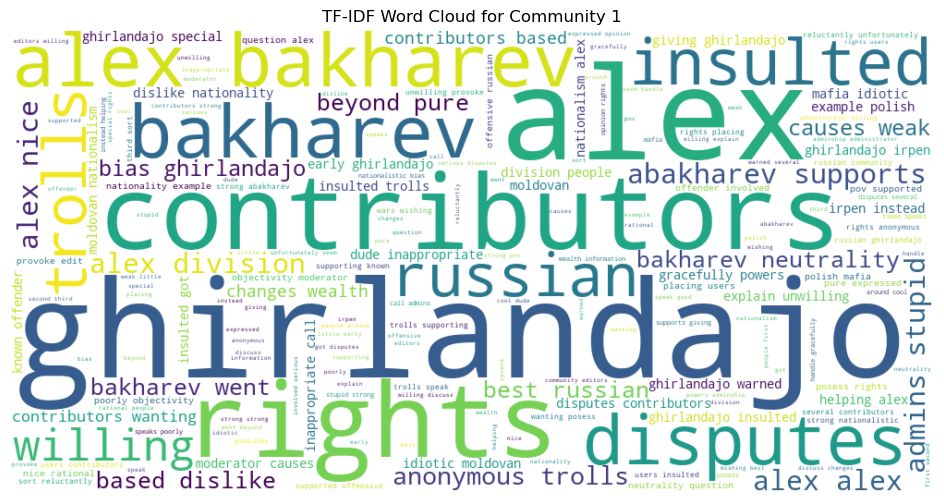

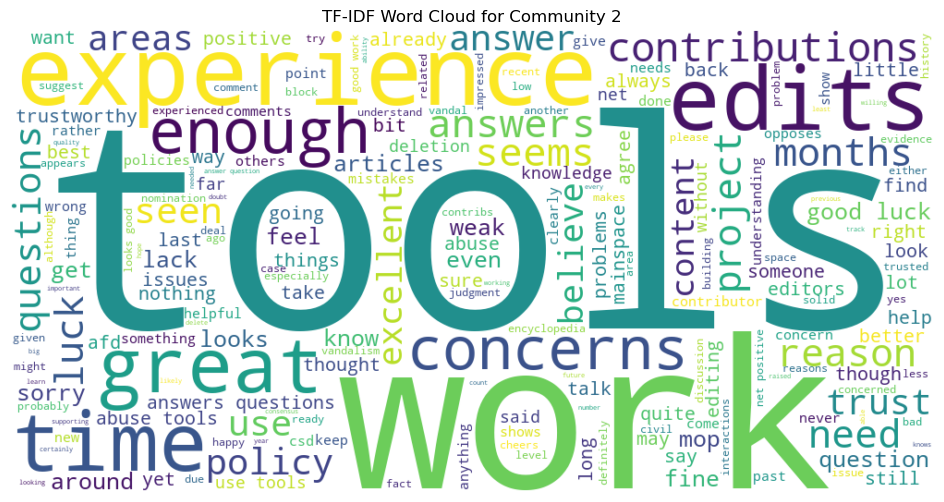

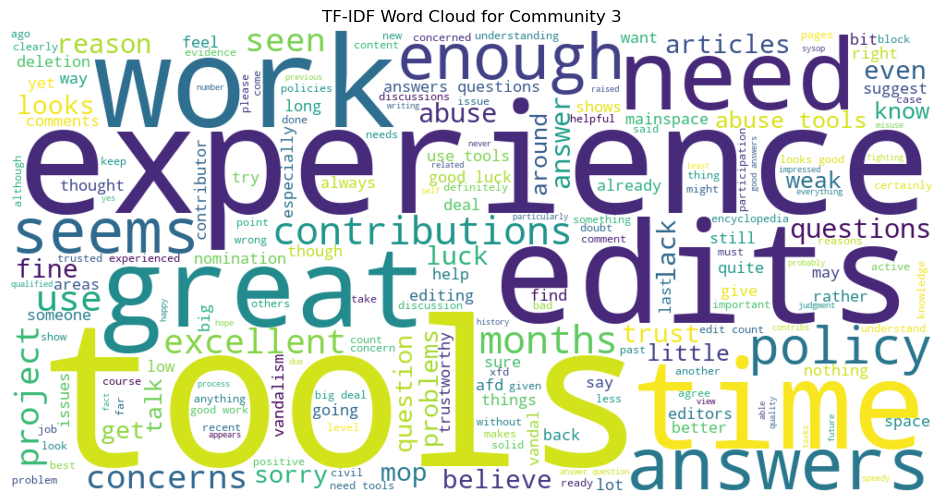

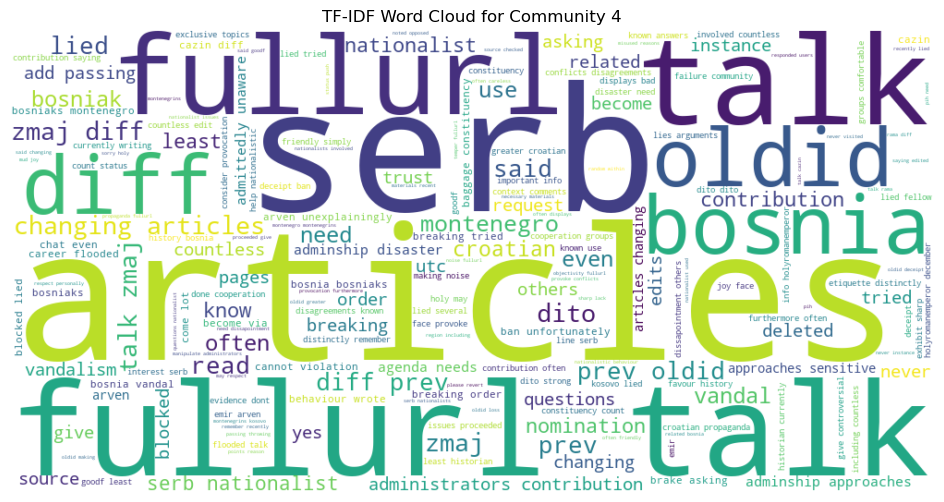

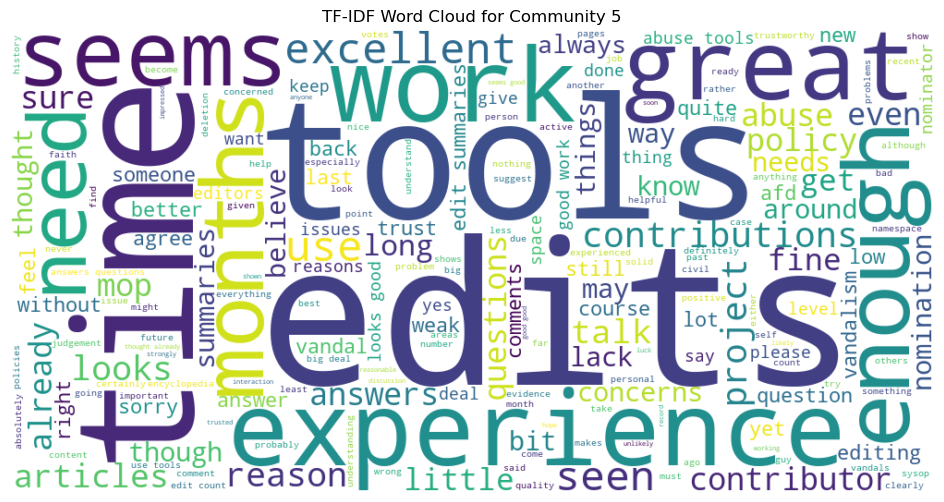

In [26]:
for c in community_ids:
    row = tfidf_df.loc[f"community_{c}"]
    
    freq_dict = row[row > 0].to_dict()

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for Community {c}")
    plt.show()

Top 4 communites seems to share their top TF-IDF words, which all seem realistic. The 2 small communites appear to have very wwierd and random words, which is most likely due to their small size and limited amount of texts. Considers only focusing on top 4 communities from here